In [55]:
import os, sys

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)


import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import torch.nn as nn
import torch
import random
from tqdm.autonotebook import tqdm
import seaborn as sns
from envs import NonStationaryEnv, IGTEnv
from basal_ganglia import train
import pickle

Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Labsystem/Rossler/ROSSLER_CLEANED_FILES


## Hyperparameters


In [56]:
TRAILS = 100
EPOCHS = 100
NUM_BINS = 5
LR = 0.1 
NUM_ARMS = 4
SCALING_FACTOR = 100
REW_STD = 0
LOSS_STD = 0
VAR = 0.1

## Simulation

In [57]:
env = IGTEnv(mean_reward=np.array([100,100,50,50])/SCALING_FACTOR,
             std_reward=np.array([REW_STD,REW_STD,REW_STD,REW_STD])/SCALING_FACTOR,
             mean_loss=np.array([-250,-1250,-50,-250])/SCALING_FACTOR,
             std_loss=np.array([LOSS_STD,LOSS_STD,LOSS_STD,LOSS_STD])/SCALING_FACTOR)

In [58]:
reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor,ep_monitor= train(env, 
                                                      trails = TRAILS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = NUM_BINS,
                                                      STN_data = None, #Taking noise
                                                      d1_amp=0.5,
                                                      d2_amp=0.1, #1
                                                      gpi_threshold=0.15,#0.18,
                                                      max_gpi_iters=50,
                                                      del_lim=None, train_IP = False, 
                                                      del_med = None, printing = True,
                                                      gpi_mean= 1, ep_0 = 0.1,
                                                      alpha_ep = 0.001,
                                                      eta_ep = 0.1,
                                                      baseline_ep = 0.02, ep_lim=0.25)


0: dp: tensor([[0.2504, 0.2504, 0.2504, 0.2504]], grad_fn=<MulBackward0>), arm_chosen:0, TD error: tensor([-1.7504], grad_fn=<RsubBackward1>), epsilon: 0.12090000510215759
1: dp: tensor([[0.2500, 0.2504, 0.2504, 0.2504]], grad_fn=<MulBackward0>), arm_chosen:3, TD error: tensor([-2.2504], grad_fn=<RsubBackward1>), epsilon: 0.1417791098356247
2: dp: tensor([[0.2500, 0.2504, 0.2504, 0.2500]], grad_fn=<MulBackward0>), arm_chosen:3, TD error: tensor([0.2500], grad_fn=<RsubBackward1>), epsilon: 0.16210205852985382
3: dp: tensor([[0.2500, 0.2504, 0.2504, 0.2500]], grad_fn=<MulBackward0>), arm_chosen:2, TD error: tensor([-0.2504], grad_fn=<RsubBackward1>), epsilon: 0.18240569531917572
4: dp: tensor([[0.2500, 0.2504, 0.2500, 0.2500]], grad_fn=<MulBackward0>), arm_chosen:0, TD error: tensor([0.7500], grad_fn=<RsubBackward1>), epsilon: 0.2032196819782257
5: dp: tensor([[0.2500, 0.2504, 0.2500, 0.2500]], grad_fn=<MulBackward0>), arm_chosen:2, TD error: tensor([-0.2500], grad_fn=<RsubBackward1>), e

## Analysis

In [59]:
A_picks = avg_counts[0]
B_picks = avg_counts[1]
C_picks = avg_counts[2]
D_picks = avg_counts[3]

Avg_A_picks = torch.mean(A_picks, dim = 0)
Avg_B_picks = torch.mean(B_picks, dim = 0)
Avg_C_picks = torch.mean(C_picks, dim = 0)
Avg_D_picks = torch.mean(D_picks, dim = 0)

IGT_score = torch.mean(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0).squeeze().numpy()
IGT_dev = torch.std(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0)/torch.sqrt(torch.tensor(EPOCHS, dtype = torch.float32))
IGT_dev = IGT_dev.squeeze().numpy()

print(f'IGT score: {IGT_score} with SE of {IGT_dev}')

IGT score: [-1.22  0.96  4.    3.9   6.52] with SE of [1.6798016 1.7739938 1.5517992 1.5919939 1.3872784]


In [60]:
A_picks = avg_counts[0]
B_picks = avg_counts[1]
C_picks = avg_counts[2]
D_picks = avg_counts[3]

Avg_A_picks = torch.mean(A_picks, dim = 0)
Avg_B_picks = torch.mean(B_picks, dim = 0)
Avg_C_picks = torch.mean(C_picks, dim = 0)
Avg_D_picks = torch.mean(D_picks, dim = 0)

IP_A = torch.mean(ip_monitor[0], dim = 0).detach().numpy()
IP_B = torch.mean(ip_monitor[1], dim = 0).detach().numpy()
IP_C = torch.mean(ip_monitor[2], dim = 0).detach().numpy()
IP_D = torch.mean(ip_monitor[3], dim = 0).detach().numpy()

DP_A = torch.mean(dp_monitor[0], dim = 0).detach().numpy()
DP_B = torch.mean(dp_monitor[1], dim = 0).detach().numpy()
DP_C = torch.mean(dp_monitor[2], dim = 0).detach().numpy()
DP_D = torch.mean(dp_monitor[3], dim = 0).detach().numpy()

IGT_score = torch.mean(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0)
IGT_dev = torch.std(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0)/torch.sqrt(torch.tensor(EPOCHS, dtype = torch.float32))

IP_all = np.array([IP_A[:,0],IP_B[:,0],IP_C[:,0],IP_D[:,0]])
IP_Var = np.std(IP_all,axis = 0 )

## Results

Text(0.5, 0, 'trails')

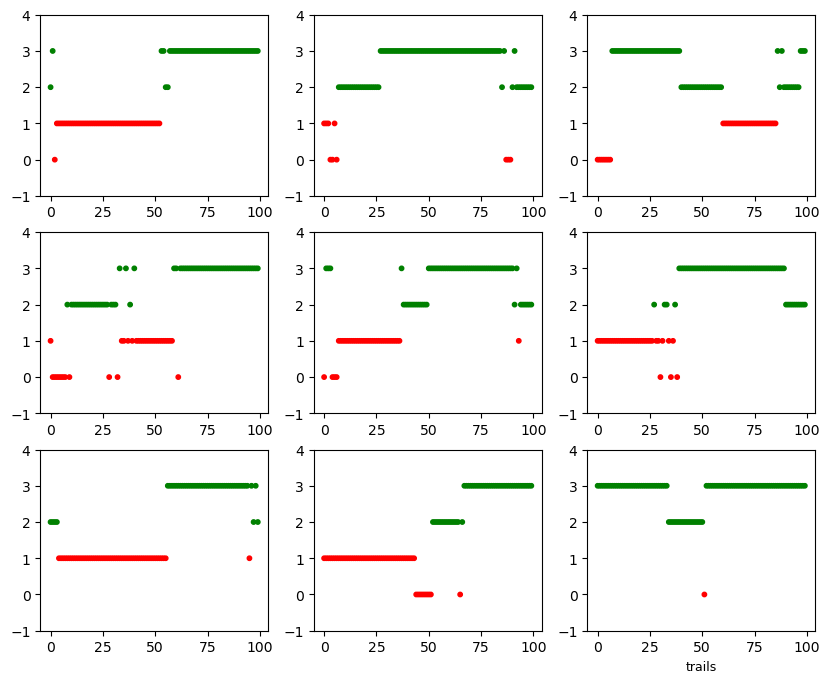

In [61]:
random_pick = np.random.choice(np.arange(EPOCHS), size = 9)

plt.figure(figsize=(10,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    colors = np.where(np.isin(arm_chosen_monitor[random_pick[i]],[0,1]), 'r', 'g')
    plt.scatter(np.arange(TRAILS), arm_chosen_monitor[random_pick[i]], c = colors, s = 10)
    plt.ylim(-1,4)
plt.xlabel('trails', fontsize = 9)


tensor([[-1.2200],
        [ 0.9600],
        [ 4.0000],
        [ 3.9000],
        [ 6.5200]]) tensor([[1.6798],
        [1.7740],
        [1.5518],
        [1.5920],
        [1.3873]])


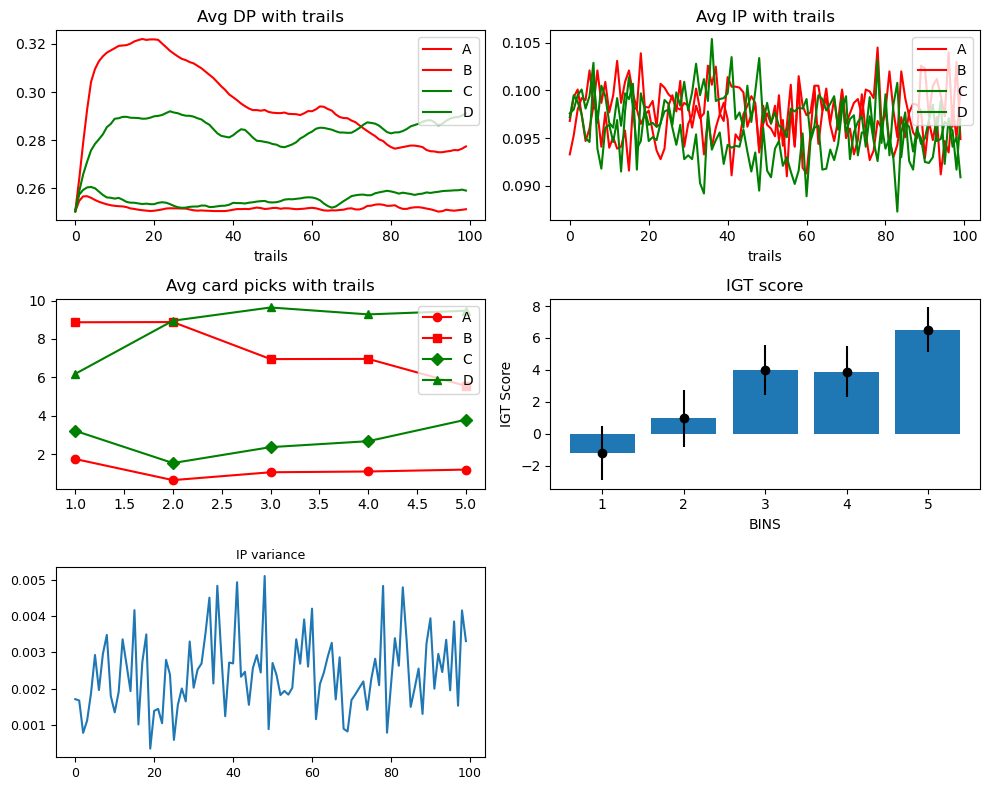

In [62]:
BINS = np.arange(5) + 1

plt.figure(figsize=(10,8))

plt.subplot(321)
plt.plot(np.arange(100), DP_A, label = 'A', color = 'red')
plt.plot(np.arange(100), DP_B, label = 'B', color = 'red')
plt.plot(np.arange(100), DP_C, label = 'C', color = 'green')
plt.plot(np.arange(100), DP_D, label = 'D', color = 'green')
plt.xlabel('trails')
plt.title('Avg DP with trails')
plt.legend(loc = 'upper right')

plt.subplot(322)
plt.plot(np.arange(100), IP_A, label = 'A', color = 'red')
plt.plot(np.arange(100), IP_B, label = 'B', color = 'red')
plt.plot(np.arange(100), IP_C, label = 'C', color = 'green')
plt.plot(np.arange(100), IP_D, label = 'D', color = 'green')
plt.xlabel('trails')
plt.title('Avg IP with trails')
plt.legend(loc = 'upper right')

plt.subplot(323)
plt.plot(BINS,Avg_A_picks, label = 'A', color = 'red', marker = 'o')
plt.plot(BINS,Avg_B_picks, label = 'B', color = 'red', marker = 's')
plt.plot(BINS,Avg_C_picks, label = 'C', color = 'green', marker = 'D')
plt.plot(BINS,Avg_D_picks, label = 'D', color = 'green', marker = '^')
plt.title('Avg card picks with trails')
plt.legend(loc = 'upper right')

plt.subplot(324)
plt.bar(BINS, IGT_score.reshape(5))
print(IGT_score, IGT_dev)
plt.errorbar(BINS, IGT_score.reshape(5), yerr= IGT_dev.reshape(5), fmt='o', color = 'black')
plt.title(f'IGT score')
plt.xlabel('BINS')
plt.ylabel('IGT Score')

plt.subplot(325)
plt.plot(IP_Var)
# plt.ylim(0.0,0.0025)
plt.title('IP variance', fontsize = 9)
plt.xticks(fontsize = 9)
plt.yticks(fontsize = 9)
plt.tight_layout()

plt.tight_layout()

In [63]:
IGT_expt= np.array([-1.83,1.5,2.6,4.59,3.9])
IGT_Simulated = IGT_score.reshape(5)

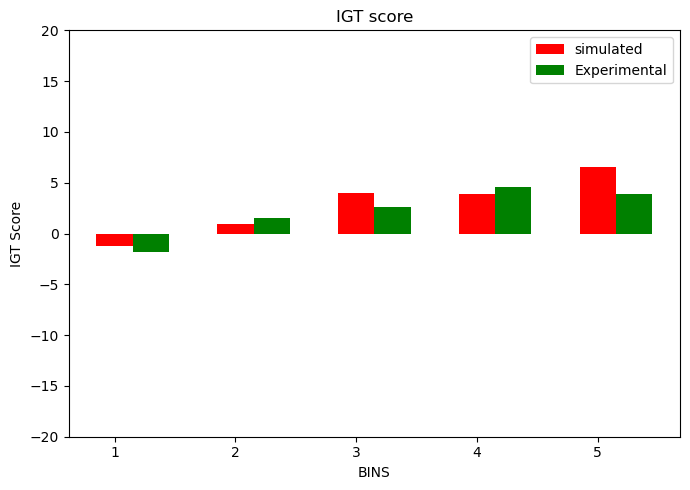

In [64]:
# Plotting bar for IGT
plt.figure(figsize=(7,5))
plt.bar(BINS, IGT_Simulated, width=0.3, color = 'red', label = 'simulated')
plt.bar(BINS+0.3, IGT_expt, width=0.3, color = 'green', label = 'Experimental')
plt.ylim(-20,20)
plt.title(f'IGT score')
plt.xlabel('BINS')
plt.ylabel('IGT Score')
plt.legend()
plt.tight_layout()

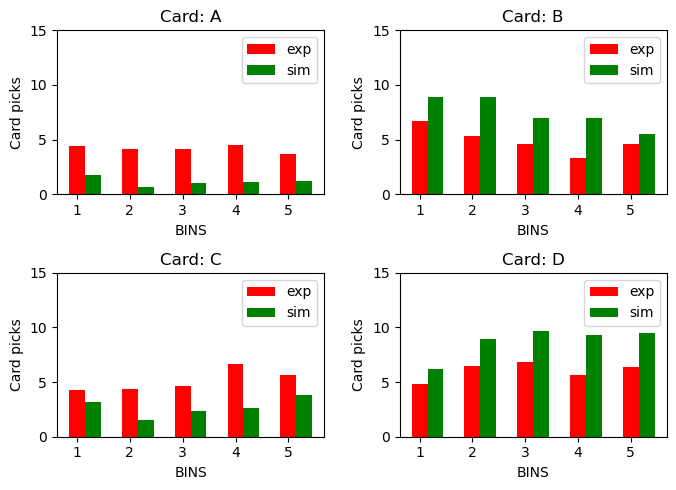

In [65]:
# Comparison each card pick wise
A_experimental = torch.tensor([4.42,4.12,4.1,4.5,3.68])
A_simulated = Avg_A_picks.squeeze()

B_experimental = torch.tensor([6.74,5.35,4.59,3.3,4.57])
B_simulated = Avg_B_picks.squeeze()

C_experimental = torch.tensor([4.28,4.34, 4.63,6.64, 5.63])
C_simulated = Avg_C_picks.squeeze()

D_experimental = torch.tensor([4.83, 6.48, 6.87, 5.68, 6.39])
D_simulated = Avg_D_picks.squeeze()

# Plotting bar chart for card picks
plt.figure(figsize=(7,5))
plt.subplot(221)
plt.bar(BINS, A_experimental, width=0.3, color = 'red', label = 'exp')
plt.bar(BINS+0.3, A_simulated, width=0.3, color = 'green', label = 'sim')
plt.ylim(0,15)
plt.title('Card: A')
plt.xlabel('BINS')
plt.ylabel('Card picks')
plt.legend()

plt.subplot(222)
plt.bar(BINS, B_experimental, width=0.3, color = 'red', label = 'exp')
plt.bar(BINS+0.3, B_simulated, width=0.3, color = 'green', label = 'sim')
plt.ylim(0,15)
plt.title('Card: B')
plt.xlabel('BINS')
plt.ylabel('Card picks')
plt.legend()

plt.subplot(223)
plt.bar(BINS, C_experimental, width=0.3, color = 'red', label = 'exp')
plt.bar(BINS+0.3, C_simulated, width=0.3, color = 'green', label = 'sim')
plt.ylim(0,15)
plt.title('Card: C')
plt.xlabel('BINS')
plt.ylabel('Card picks')
plt.legend()

plt.subplot(224)
plt.bar(BINS, D_experimental, width=0.3, color = 'red', label = 'exp')
plt.bar(BINS+0.3, D_simulated, width=0.3, color = 'green', label = 'sim')
plt.ylim(0,15)
plt.title('Card: D')
plt.xlabel('BINS')
plt.ylabel('Card picks')
plt.legend()

plt.tight_layout()

## Statistical testing

In [66]:
mean_sim = IGT_score.squeeze().detach().numpy()
mean_expt = IGT_expt
std_sim = torch.std(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0).squeeze().detach().numpy()
std_expt = std_sim
n_sim = 100
n_expt = 20

In [67]:
import math
from scipy.stats import t
import pandas as pd

def compare_multiple_pairs(mean_exp, std_exp, n_exp, mean_sim, std_sim, n_sim):
    results = []

    for i in range(len(mean_exp)):
        m1, s1 = mean_exp[i], std_exp[i]
        m2, s2 = mean_sim[i], std_sim[i]

        # Standard error
        se = math.sqrt((s1**2)/n_exp + (s2**2)/n_sim)

        # t-statistic
        t_stat = (m1 - m2) / se

        # Degrees of freedom (Welch-Satterthwaite)
        df_num = (s1**2/n_exp + s2**2/n_sim)**2
        df_den = ((s1**2/n_exp)**2 / (n_exp - 1)) + ((s2**2/n_sim)**2 / (n_sim - 1))
        df = df_num / df_den

        # Two-tailed p-value
        p_val = 2 * (1 - t.cdf(abs(t_stat), df))
        conclusion = "Statistically different" if p_val < 0.05 else "Not statistically different"

        results.append({
            "Index": i+1,
            "Exp Mean": m1,
            "Sim Mean": m2,
            "t-stat": round(t_stat, 3),
            "p-value": round(p_val, 4),
            "Significant": p_val < 0.05,
            "Conclusion": conclusion

        })

    return pd.DataFrame(results)

# Run comparison
df_results_IGT_mean = compare_multiple_pairs(mean_expt, std_expt, n_expt, mean_sim, std_sim, n_sim)

# Show results
# import ace_tools as tools; tools.display_dataframe_to_user(name="Significance Comparison Results", dataframe=df_results)


In [68]:
df_results_IGT_mean

,Index,Exp Mean,Sim Mean,t-stat,p-value,Significant,Conclusion
0,1,-1.83,-1.22,-0.148,0.8832,False,Not statistically different
1,2,1.50,0.96,0.124,0.9020,False,Not statistically different
2,3,2.60,4.00,-0.368,0.7155,False,Not statistically different
3,4,4.59,3.90,0.177,0.8609,False,Not statistically different
4,5,3.90,6.52,-0.771,0.4474,False,Not statistically different


## Saving data

In [ ]:
# data_normal = {'IGT_sim': mean_sim,
#                'IGT_sim_std': std_sim,
#                'IGT_exp': mean_expt,
#                'IGT_exp_std': std_expt,
#                'n_expt': n_expt,
#                'n_sim': n_sim,
#                'article': 'Gescheidt',
#                'condition': 'normal',
#                'A_experimental': A_experimental,
#                'B_experimental': B_experimental,
#                'C_experimental': C_experimental,
#                'D_experimental': D_experimental,
#                'A_simulated': A_simulated,
#                'B_simulated': B_simulated,
#                'C_simulated': C_simulated,
#                'D_simulated': D_simulated,
#                'statistical test': df_results_IGT_mean}

In [70]:
# # saving as pickle file

# with open('data_normal_igt.pkl', 'wb') as f:
#     pickle.dump(data_normal, f)